# Logistic Regression

🔹 Logistic Regression Problem Statement (Employee Attrition Prediction)

In this use case, we aim to predict whether an employee will leave the company (attrition) or stay based on features such as age, gender, department, salary, bonus, years of experience, performance score, certifications, and remote work percentage. The target variable is binary (1 = Left, 0 = Stayed), making this a classification problem. The objective is to build a model (using Logistic Regression) that estimates the probability of attrition for each employee. This helps HR and management to identify at-risk employees early, implement retention strategies, and reduce turnover costs.

## 1) Mathematical Background

**Logistic regression** models the probability that a binary target $y\in\{0,1\}$ equals 1 given features $x$. Key formulae:

 **Sigmoid (logistic) function** to map real-valued z to (0,1):

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$





## 2) Practical Notebook

In [2]:
# ---- Imports & Setup ----
# We'll import all necessary libraries

import warnings  # standard library warnings module
warnings.filterwarnings('ignore')  # hide non-critical warnings to keep output readable

import pandas as pd  # data handling with DataFrame
import numpy as np   # numerical computing
from pathlib import Path  # easy path manipulations, works cross-platform

# visualization
import matplotlib.pyplot as plt  # low-level plotting primitives
import seaborn as sns  # high-level plotting functions built on matplotlib

# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV  # splitting and hyperparameter search
from sklearn.preprocessing import StandardScaler  # feature scaling (zero mean, unit variance)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier  # random forest classifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, auc
)  # evaluation metrics

import joblib  # for saving/loading models

# Notebook visualization preferences and paths
sns.set_theme(style='whitegrid')  # set seaborn style for nicer plots
%matplotlib inline

# ---- File Paths ----
DATA_PATH= Path("loan_default_sample.csv")

# Create an output directory for results (models, plots, etc.)
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)
print("Output directory ready at:", OUTPUT_DIR.resolve())


Output directory ready at: C:\Users\Pc\Downloads\output


In [3]:
# ---- Load data ----
# Read CSV into pandas DataFrame. parse_dates would be used if date columns exist.
df = pd.read_csv(r"C:\Users\Pc\Downloads\loan_default_sample.csv")

# Print shape and head for quick sanity checks.
print('Dataset shape (rows, cols):', df.shape)
display(df.head())  
print (df.tail()) # display() is Jupyter-friendly and shows a prettier table
print('\nData types:')
print(df.dtypes)

Dataset shape (rows, cols): (500, 14)


,loan_id,age,annual_income,employment_length,home_ownership,purpose,loan_amount,term_months,interest_rate,dti,credit_score,delinquency_2yrs,num_open_acc,target_default
0,L100000,24,48586.06,2,MORTGAGE,other,18943.19,60,13.31,17.75,746.0,3,7,0
1,L100001,55,23634.07,17,MORTGAGE,debt_consolidation,15802.09,36,14.34,13.33,713.0,1,14,0
2,L100002,49,27994.32,6,OWN,other,17309.60,36,8.37,18.95,601.0,3,12,1
3,L100003,40,81938.71,17,MORTGAGE,debt_consolidation,20443.27,36,12.15,20.54,717.0,3,12,0
4,L100004,40,30688.66,20,RENT,other,9333.60,36,5.00,11.73,552.0,4,1,1


     loan_id  age  annual_income  employment_length home_ownership  \
495  L100495   39       61666.51                  1           RENT   
496  L100496   26       62105.12                 29           RENT   
497  L100497   37       25701.92                 13           RENT   
498  L100498   61       16290.97                  8            OWN   
499  L100499   39       65026.18                 26       MORTGAGE   

                purpose  loan_amount  term_months  interest_rate    dti  \
495         credit_card      1747.80           36           9.27   2.83   
496  debt_consolidation     16520.91           36          20.13  29.37   
497         credit_card     26025.58           36          11.87  25.49   
498  debt_consolidation     18420.68           60          16.11   5.64   
499  debt_consolidation     16194.38           36          11.79  15.57   

     credit_score  delinquency_2yrs  num_open_acc  target_default  
495         617.0                 4            12           

In [4]:
# ---- Data overview & cleaning ----
# 1) Missing values count per column: useful to decide imputation strategy
print('Missing values per column:\n', df.isnull().sum())

# 2) Remove exact duplicates (rare in synthetic data, but best practice)
dupes = df.duplicated().sum()
print('Duplicate rows:', dupes)
if dupes > 0:
    df = df.drop_duplicates()

# 3) Impute numeric missing values with median (robust choice)
numeric_cols = ['age  ','annual_income','employment_length  ','loan_amount','term_months','interest_rate','dti ','credit_score','delinquency_2yrs','num_open_acc','target_default']
for col in numeric_cols:
    if col in df.columns:
        median_val = df[col].median()  # compute median ignoring NaNs
        # fillna replaces NaN values with the median; this preserves dtype
        df[col] = df[col].fillna(median_val)

print('\nMissing values after imputation:\n', df.isnull().sum())

# 4) Show categorical distributions for sanity checks (helps to detect typos)
print('\nhome_ownership:'); print(df['home_ownership'].value_counts())
print('\npurpose distribution:'); print(df['purpose'].value_counts())

Missing values per column:
 loan_id              0
age                  0
annual_income        0
employment_length    0
home_ownership       0
purpose              0
loan_amount          0
term_months          0
interest_rate        0
dti                  0
credit_score         0
delinquency_2yrs     0
num_open_acc         0
target_default       0
dtype: int64
Duplicate rows: 0

Missing values after imputation:
 loan_id              0
age                  0
annual_income        0
employment_length    0
home_ownership       0
purpose              0
loan_amount          0
term_months          0
interest_rate        0
dti                  0
credit_score         0
delinquency_2yrs     0
num_open_acc         0
target_default       0
dtype: int64

home_ownership:
home_ownership
OWN         179
MORTGAGE    162
RENT        159
Name: count, dtype: int64

purpose distribution:
purpose
other                 135
credit_card           123
home_improvement      122
debt_consolidation    120
Name: co

In [6]:
purpose = df['purpose'].unique().tolist()
print(purpose)

['other', 'debt_consolidation', 'home_improvement', 'credit_card']


In [7]:
home_ownership=df['home_ownership'].unique().tolist()
print(home_ownership)

['MORTGAGE', 'OWN', 'RENT']


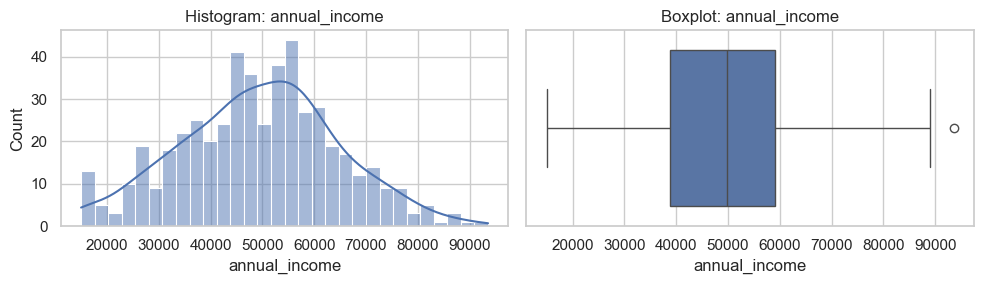

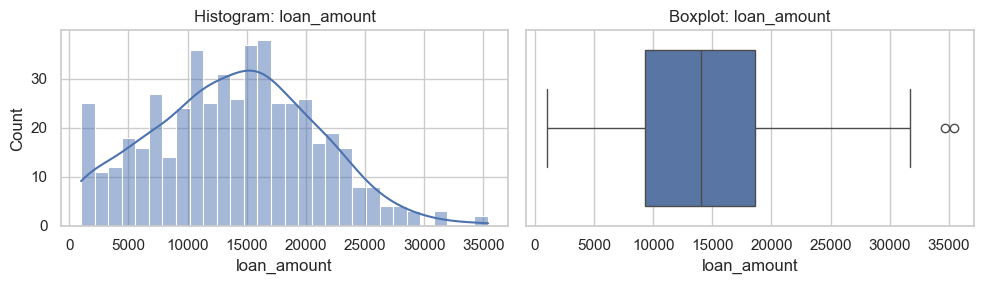

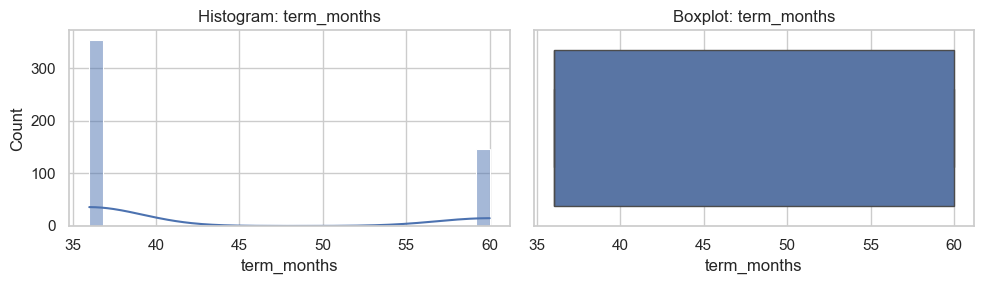

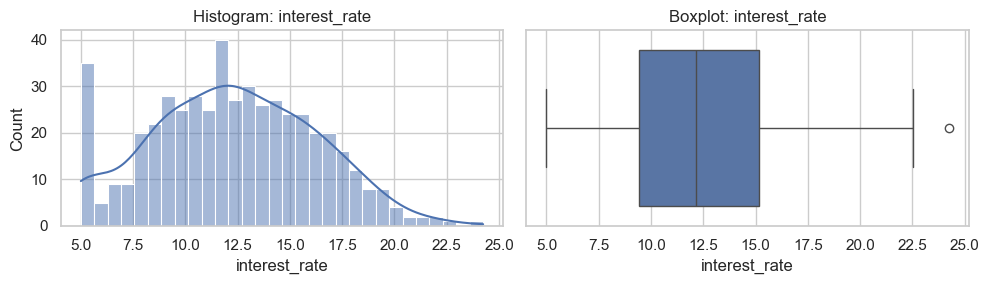

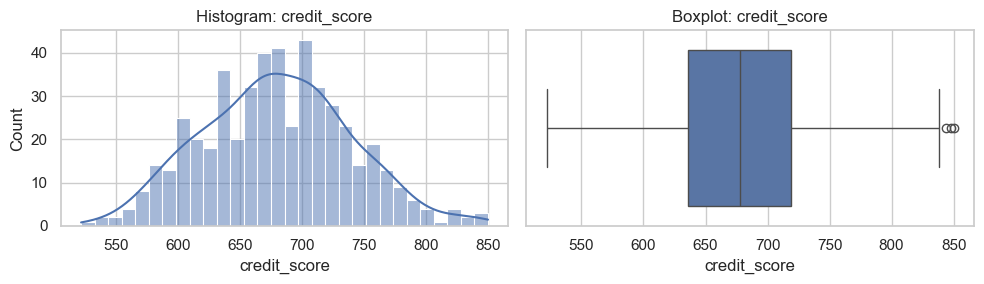

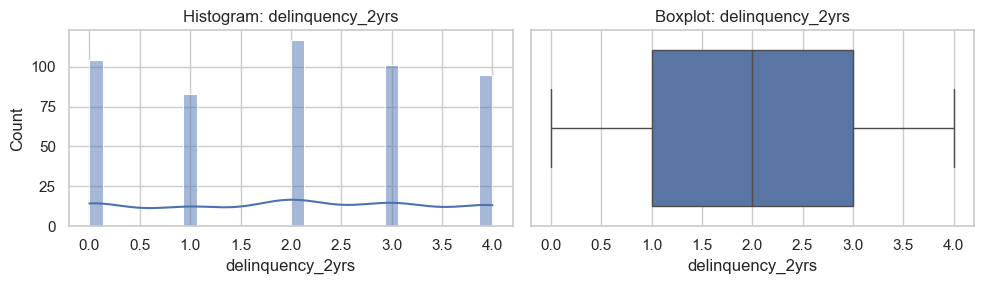

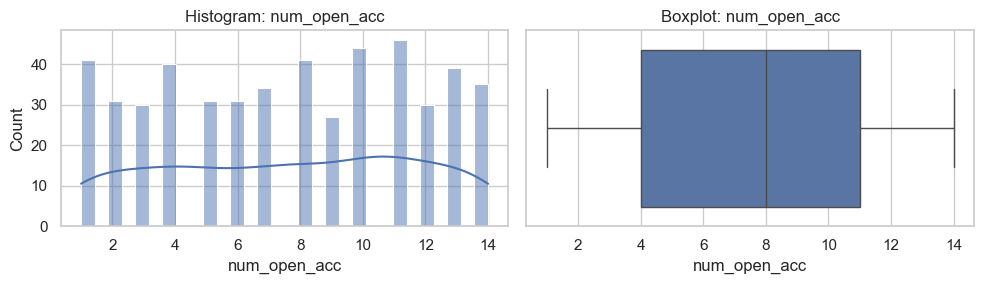

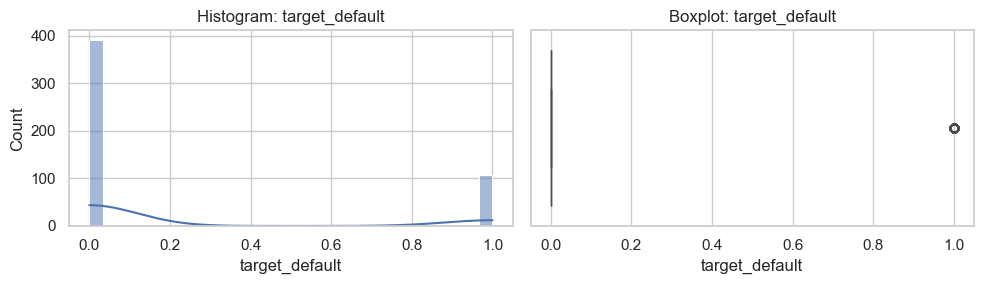

In [4]:
# ---- Univariate Analysis ----
# We examine distribution of numeric features via histogram + boxplot to see skew and outliers.
numeric_cols = ['age  ','annual_income','employment_length  ','loan_amount','term_months','interest_rate','dti ','credit_score','delinquency_2yrs','num_open_acc','target_default']
numeric_cols = [c for c in numeric_cols if c in df.columns]

for col in numeric_cols:
    plt.figure(figsize=(10,3))
    plt.subplot(1,2,1)
    # histplot: draws histogram and an optional KDE for smoothed density
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f'Histogram: {col}')
    plt.subplot(1,2,2)
    # boxplot: shows quartiles (Q1,Q2,Q3) and whiskers (1.5*IQR by default)
    sns.boxplot(x=df[col].dropna())
    plt.title(f'Boxplot: {col}')
    plt.tight_layout()
    plt.show()

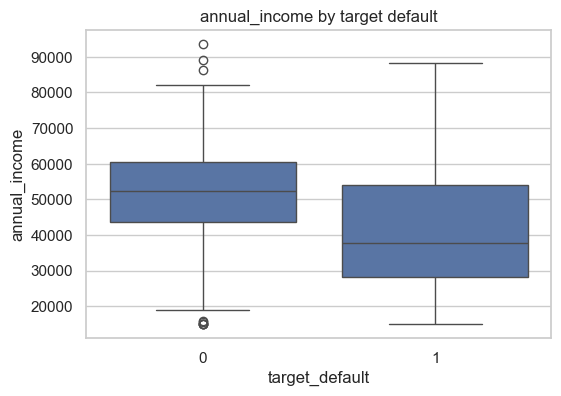

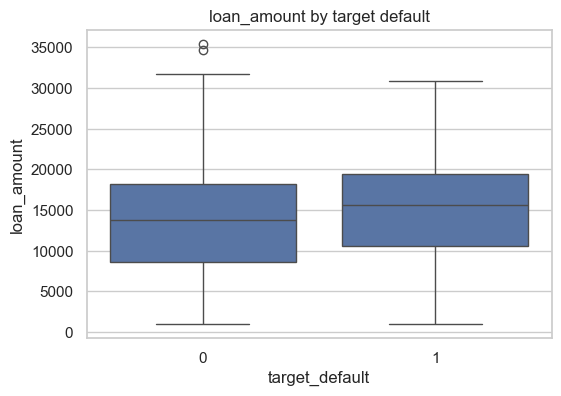

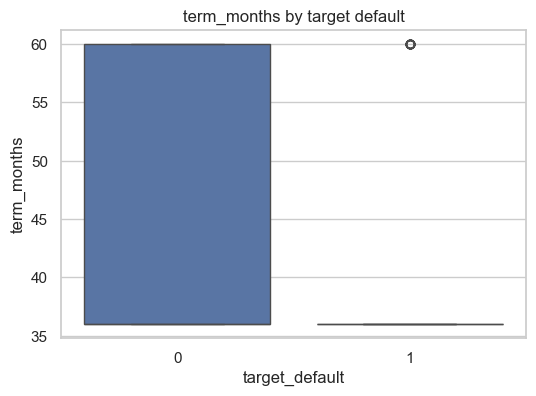

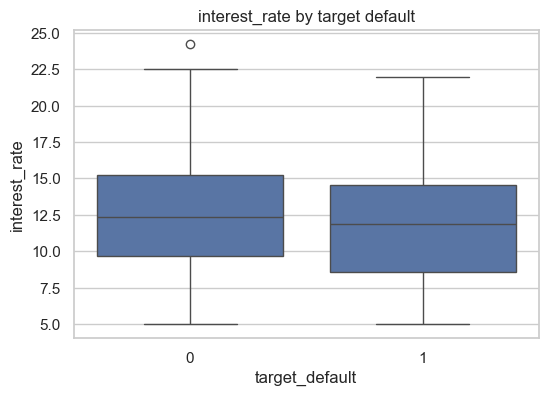

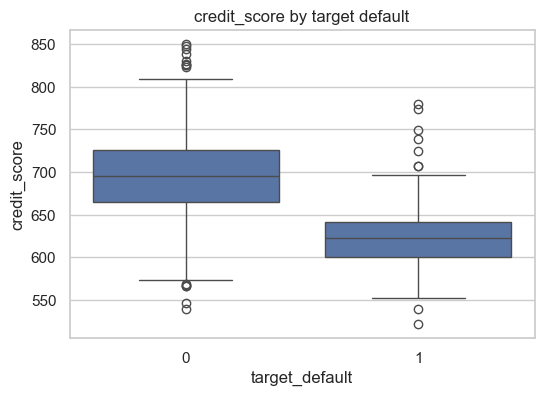

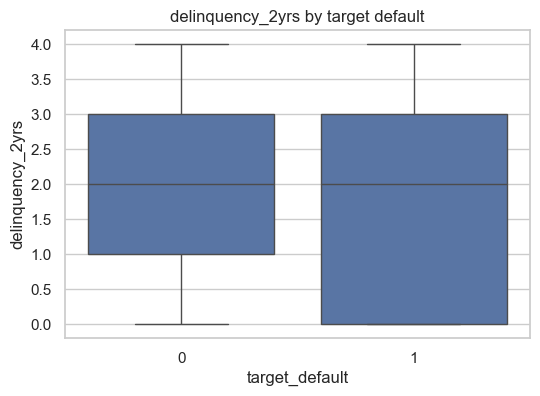

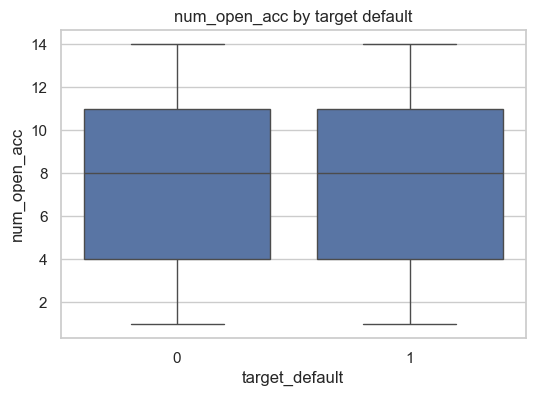

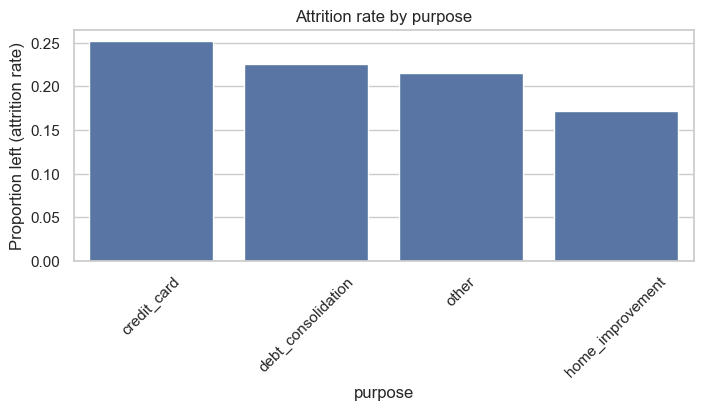

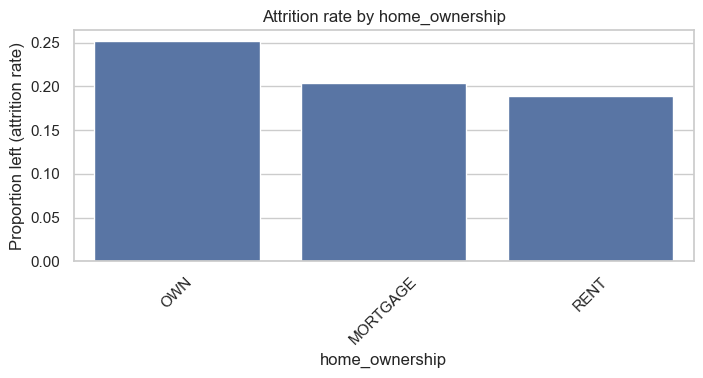

In [5]:
# ---- Bivariate Analysis (target vs features) ----
# For numeric features: boxplots grouped by target class (0=Stayed,1=Left)
num_feats = ['age  ','annual_income','employment_length  ','loan_amount','term_months','interest_rate','dti ','credit_score','delinquency_2yrs','num_open_acc']
num_feats = [c for c in num_feats if c in df.columns]

for feat in num_feats:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='target_default', y=feat, data=df)
    plt.title(f'{feat} by target default')
    plt.show()

# For categorical: compute proportion left per category and plot
cat_feats =['purpose','home_ownership']
cat_feats = [c for c in cat_feats if c in df.columns]
for feat in cat_feats:
    prop = df.groupby(feat)['target_default'].mean().reset_index().sort_values('target_default', ascending=False)
    plt.figure(figsize=(8,3))
    sns.barplot(x=feat, y='target_default', data=prop)
    plt.ylabel('Proportion left (attrition rate)')
    plt.title(f'Attrition rate by {feat}')
    plt.xticks(rotation=45)
    plt.show()

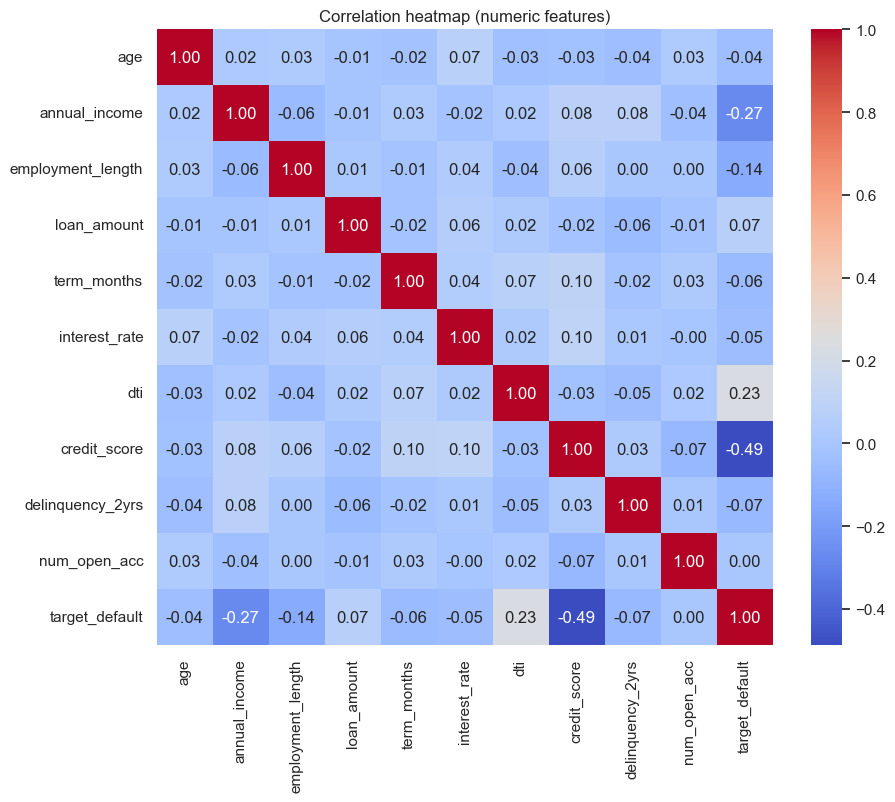

In [6]:
# ---- Correlation heatmap ----
# Correlation uses Pearson correlation coefficient which measures linear association between pairs of numeric variables.
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10,8))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation heatmap (numeric features)')
plt.show()

In [1]:
# ---- Outlier detection (IQR) ----
# IQR method identifies points outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
def iqr_bounds(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

check= ['age  ','annual_income','employment_length  ','loan_amount','term_months','interest_rate','dti ','credit_score','delinquency_2yrs','num_open_acc']

for c in check:
    if c in df.columns:
        lower, upper = iqr_bounds(df[c].dropna())
        outliers = df[(df[c] < lower) | (df[c] > upper)]
        print(f"{c}: lower={lower:.2f}, upper={upper:.2f}, count_outliers={outliers.shape[0]}")

# Note: outlier removal is optional; document any removal carefully before modeling.


NameError: name 'df' is not defined

In [8]:
# ---- Feature engineering ----
# Create derived features that may improve model performance
if 'annual_income' in df.columns and 'loan_amount' in df.columns:
   df['income_to_loan_ratio'] = df['annual_income'] / df['loan_amount']

# salary bands (categorical)
df['credit_score_binned'] = pd.cut(df['credit_score'], bins= [0, 4000, 7000,10000,14000, 18000 ], labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

df['employment_risk'] = df['employment_length'].apply(lambda x: 1 if x < 2 else 0)
display(df.head)
print('New features added (if applicable)')
display(df.head())


<bound method NDFrame.head of      loan_id  age  annual_income  employment_length home_ownership  \
0    L100000   24       48586.06                  2       MORTGAGE   
1    L100001   55       23634.07                 17       MORTGAGE   
2    L100002   49       27994.32                  6            OWN   
3    L100003   40       81938.71                 17       MORTGAGE   
4    L100004   40       30688.66                 20           RENT   
..       ...  ...            ...                ...            ...   
495  L100495   39       61666.51                  1           RENT   
496  L100496   26       62105.12                 29           RENT   
497  L100497   37       25701.92                 13           RENT   
498  L100498   61       16290.97                  8            OWN   
499  L100499   39       65026.18                 26       MORTGAGE   

                purpose  loan_amount  term_months  interest_rate    dti  \
0                 other     18943.19           60     

New features added (if applicable)


,loan_id,age,annual_income,employment_length,home_ownership,purpose,loan_amount,term_months,interest_rate,dti,credit_score,delinquency_2yrs,num_open_acc,target_default,income_to_loan_ratio,credit_score_binned,employment_risk
0,L100000,24,48586.06,2,MORTGAGE,other,18943.19,60,13.31,17.75,746.0,3,7,0,2.564830,Very Low,0
1,L100001,55,23634.07,17,MORTGAGE,debt_consolidation,15802.09,36,14.34,13.33,713.0,1,14,0,1.495629,Very Low,0
2,L100002,49,27994.32,6,OWN,other,17309.60,36,8.37,18.95,601.0,3,12,1,1.617271,Very Low,0
3,L100003,40,81938.71,17,MORTGAGE,debt_consolidation,20443.27,36,12.15,20.54,717.0,3,12,0,4.008102,Very Low,0
4,L100004,40,30688.66,20,RENT,other,9333.60,36,5.00,11.73,552.0,4,1,1,3.287977,Very Low,0


In [9]:
# ---- Prepare data for modeling ----
# Select features and handle missing values and encoding
features= ['age  ','annual_income','employment_length  ','loan_amount','term_months','interest_rate','dti ','credit_score','delinquency_2yrs','num_open_acc']

categorical = ['purpose','home_ownership']

features = [f for f in features if f in df.columns]
categorical = [c for c in categorical if c in df.columns]

# Build df_model containing features + target
df_model = df[features + categorical + ['target_default']].copy()

# Numeric imputation: median
for col in df_model.select_dtypes(include=[np.number]).columns:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Categorical imputation: mode
for col in categorical:
    df_model[col] = df_model[col].fillna(df_model[col].mode().iloc[0])

# One-hot encode categorical features; drop_first=True to avoid multicollinearity
df_model = pd.get_dummies(df_model, columns=categorical, drop_first=True)

# Separate X and y
X = df_model.drop(columns=['target_default'])
y = df_model['target_default']

# Scale numeric features: important for regularized logistic regression
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print('Prepared X shape:', X.shape)


Prepared X shape: (500, 12)


In [11]:
# ---- Train/Test Split ----
# Stratify ensures class proportions are preserved in train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape, 'Test:', X_test.shape)

# ---- Logistic Regression + GridSearch ----
# We'll search over inverse regularization strength C and class_weight option.
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
param_grid = {'C': [0.01, 0.1, 1, 10], 'class_weight': [None, 'balanced']}
grid = GridSearchCV(lr, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
best_lr = grid.best_estimator_

# Predict on test set
y_pred = best_lr.predict(X_test)
y_proba = best_lr.predict_proba(X_test)[:,1]



Train: (400, 12) Test: (100, 12)
Best params: {'C': 0.1, 'class_weight': 'balanced'}


In [12]:
# ---- Evaluation Metrics ----
# We compute standard classification metrics and explain each:
# Accuracy: (TP+TN)/total
# Precision: TP / (TP + FP) -> fraction of positive predictions that are correct
# Recall (Sensitivity): TP / (TP + FN) -> fraction of actual positives correctly identified
# F1-score: harmonic mean of precision & recall
# ROC AUC: area under ROC curve, measures ranking quality

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy: {acc:.3f}')
print(f'Precision: {prec:.3f}')
print(f'Recall: {rec:.3f}')
print(f'F1-score: {f1:.3f}')
print(f'ROC AUC: {roc_auc:.3f}\n')

print('Classification report:\n')
print(classification_report(y_test, y_pred))


Accuracy: 0.770
Precision: 0.486
Recall: 0.773
F1-score: 0.596
ROC AUC: 0.841

Classification report:

              precision    recall  f1-score   support

           0       0.92      0.77      0.84        78
           1       0.49      0.77      0.60        22

    accuracy                           0.77       100
   macro avg       0.70      0.77      0.72       100
weighted avg       0.83      0.77      0.79       100



In [13]:
rf = RandomForestClassifier(
    n_estimators=100,   # number of trees
    max_depth=None,     # grow trees until all leaves are pure
    random_state=42
)
print((rf.get_params()))

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]


{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [ ]:
# Accuracy for random forest classifier 
acc= accuracy_score(y_test,y_pred)
# preciison  for random forest classifier 
pres= precision_score(y_test, y_pred)
# classification report  for random forest classifier 
print(classification_report(y_test, y_pred))
f1=f1_score(y_test,y_pred)
# recall  for random forest classifier 
recall= recall_score(y_test,y_pred)
# ROC AUC  for random forest classifier 
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", roc_auc)

              precision    recall  f1-score   support

           0       0.89      0.94      0.91        78
           1       0.72      0.59      0.65        22

    accuracy                           0.86       100
   macro avg       0.81      0.76      0.78       100
weighted avg       0.85      0.86      0.85       100

ROC AUC: 0.8889860139860142


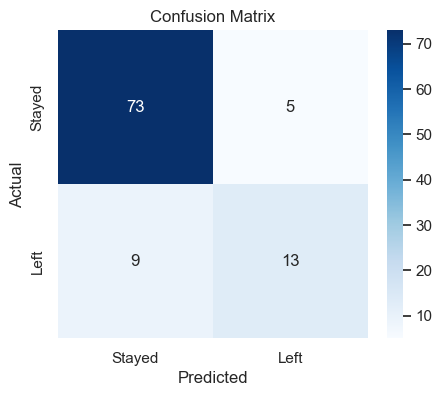

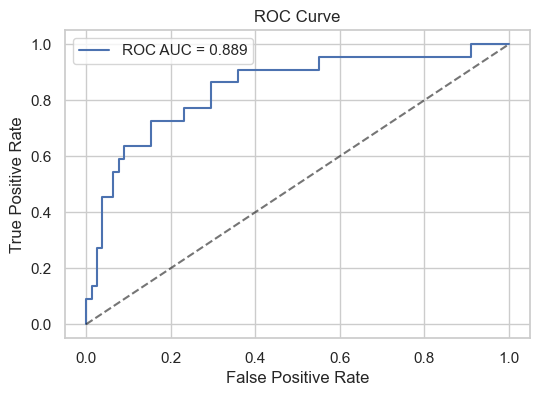

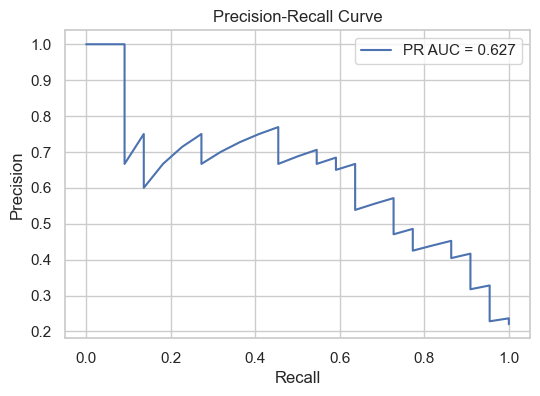

In [15]:
# ---- Diagnostic Plots ----
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed','Left'], yticklabels=['Stayed','Left'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--', alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


### Coefficients and Odds Ratios

In logistic regression, each coefficient $\beta_j$ represents the change in **log-odds** associated with a one-unit increase in feature $x_j$, holding other features constant:

$$ \Delta \log\left(\frac{p}{1-p}\right) = \beta_j \Delta x_j $$

Exponentiating converts log-odds differences to **odds ratios**:

$$ \text{odds ratio} = e^{\beta_j} $$

An odds ratio >1 means higher odds of the event (y=1) as the feature increases; <1 means lower odds.

Top positive contributors:


,coef (log-odds),odds_ratio
loan_amount,0.243097,1.275193
term_months,0.009384,1.009428
home_ownership_OWN,-0.002928,0.997076
num_open_acc,-0.056930,0.944660
purpose_other,-0.092740,0.911431
delinquency_2yrs,-0.115432,0.890981
interest_rate,-0.116014,0.890463
purpose_debt_consolidation,-0.135511,0.873270
home_ownership_RENT,-0.448845,0.638365
purpose_home_improvement,-0.475955,0.621292



Top negative contributors:


,coef (log-odds),odds_ratio
home_ownership_OWN,-0.002928,0.997076
num_open_acc,-0.056930,0.944660
purpose_other,-0.092740,0.911431
delinquency_2yrs,-0.115432,0.890981
interest_rate,-0.116014,0.890463
purpose_debt_consolidation,-0.135511,0.873270
home_ownership_RENT,-0.448845,0.638365
purpose_home_improvement,-0.475955,0.621292
annual_income,-0.585003,0.557104
credit_score,-1.433185,0.238548


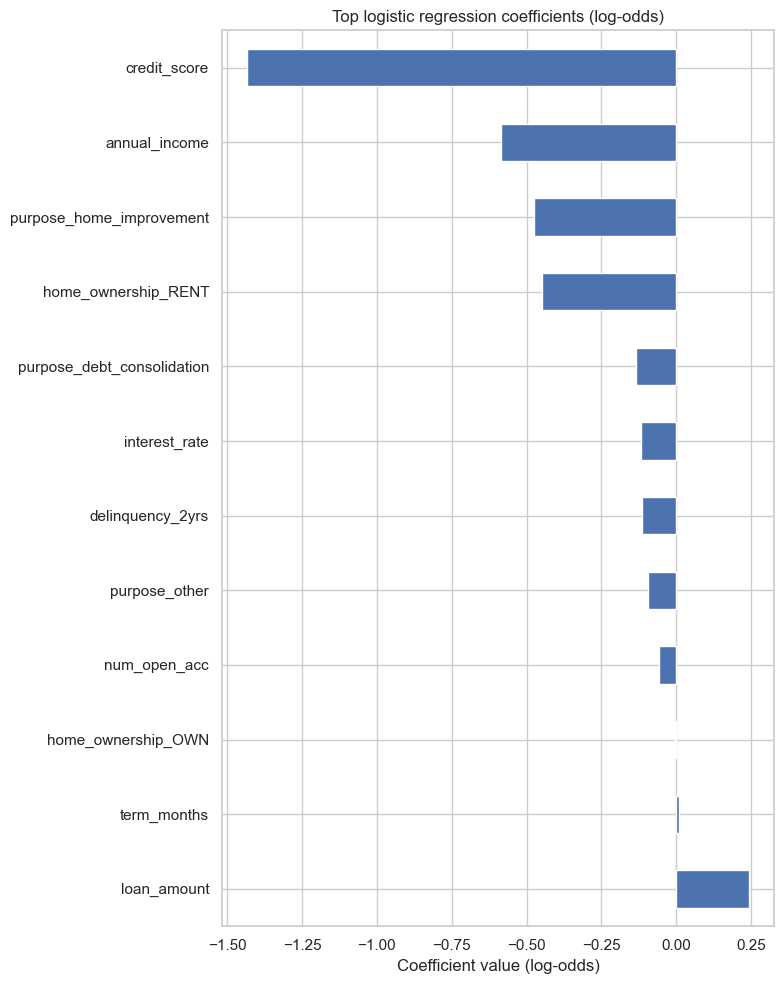

In [16]:
# ---- Coefficients & Odds Ratios ----
coeffs = pd.Series(best_lr.coef_[0], index=X.columns).sort_values(ascending=False)
odds = np.exp(coeffs)
feat_df = pd.concat([coeffs, odds], axis=1)
feat_df.columns = ['coef (log-odds)','odds_ratio']
# Display top positive and negative features
print('Top positive contributors:')
display(feat_df.head(10))
print('\nTop negative contributors:')
display(feat_df.tail(10))

# Plot coefficients (log-odds)
plt.figure(figsize=(8,10))
coeffs.head(20).plot(kind='barh')
plt.title('Top logistic regression coefficients (log-odds)')
plt.xlabel('Coefficient value (log-odds)')
plt.tight_layout()
plt.show()


In [17]:
# ---- Save artifacts ----
# Save cleaned data and trained model for reproducibility
cleaned_path = OUTPUT_DIR / 'cleaned_loan_default_sample.csv'
df.to_csv(cleaned_path, index=False)
model_path = OUTPUT_DIR / 'logistic_model_detailed.joblib'
joblib.dump(best_lr, model_path)
print('Saved cleaned data to', cleaned_path)
print('Saved model to', model_path)


Saved cleaned data to output\cleaned_loan_default_sample.csv
Saved model to output\logistic_model_detailed.joblib
